In [30]:
import pandas as pd
walmart_data = pd.read_csv('Walmart_Sales.csv')
walmart_data

,Store,Date,Weekly_Revenue,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05/02/2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12/02/2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19/02/2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26/02/2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05/03/2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28/09/2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05/10/2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12/10/2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19/10/2012,718125.53,0,56.47,3.969,192.330854,8.667


In [74]:
import pandas as pd
import sklearn as sk

from sklearn.tree import DecisionTreeRegressor

walmart_data = pd.read_csv('Walmart_Sales.csv')

x = walmart_data.drop(columns=['Weekly_Revenue', 'Date'])
y = walmart_data['Weekly_Revenue']

x

,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,0,42.31,2.572,211.096358,8.106
1,1,1,38.51,2.548,211.242170,8.106
2,1,0,39.93,2.514,211.289143,8.106
3,1,0,46.63,2.561,211.319643,8.106
4,1,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...
6430,45,0,64.88,3.997,192.013558,8.684
6431,45,0,64.89,3.985,192.170412,8.667
6432,45,0,54.47,4.000,192.327265,8.667
6433,45,0,56.47,3.969,192.330854,8.667


Accuracy Score in: %89.34
Predicted Weekly Sales of: $1245628.61
        Feature  Importance
0         Store   62.247709
4           CPI   18.275845
5  Unemployment   13.390205
3    Fuel_Price    3.098060
2   Temperature    2.781970
1  Holiday_Flag    0.206212


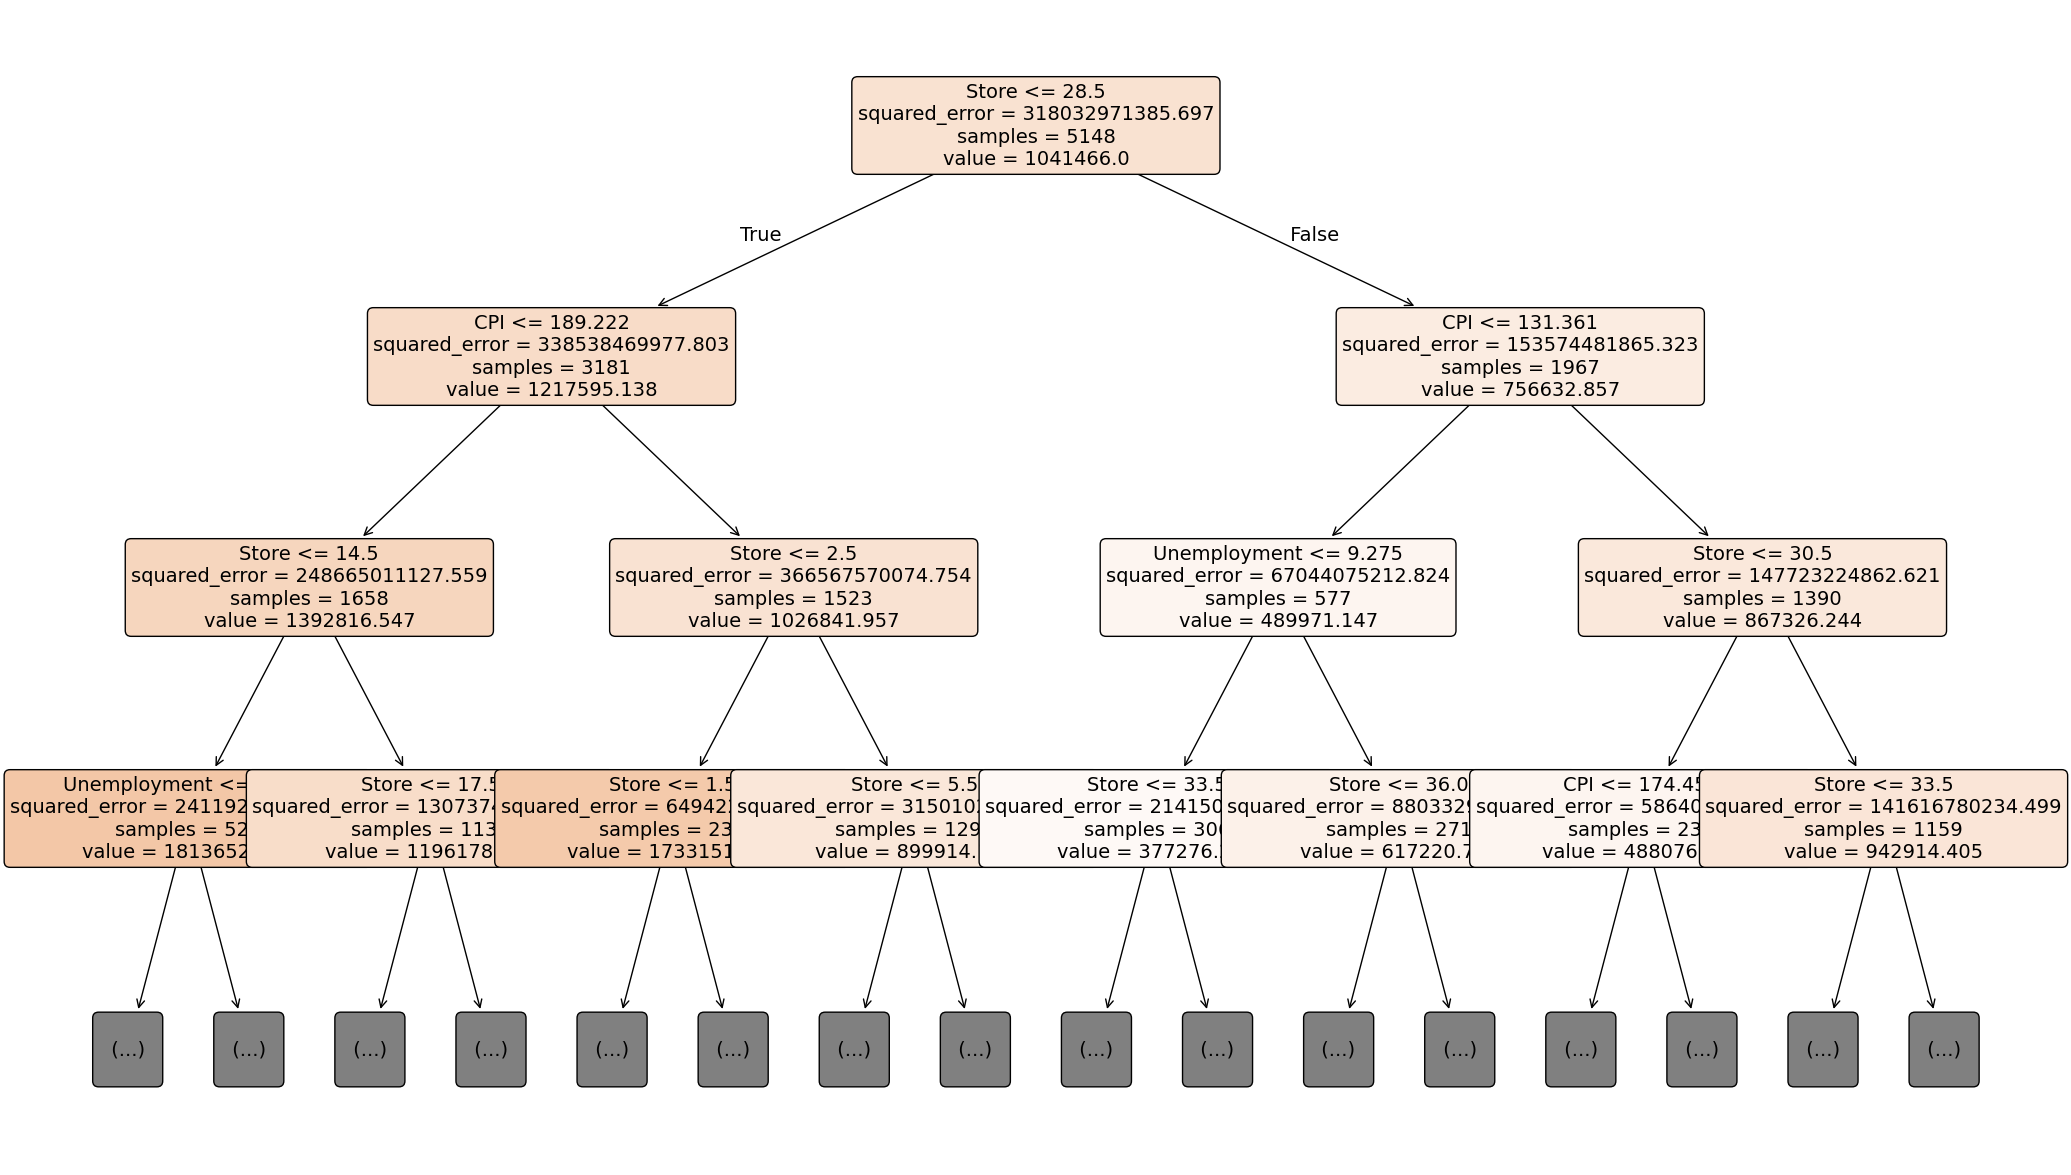

In [85]:
import pandas as pd
import sklearn as sk
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import tree

walmart_data = pd.read_csv('Walmart_Sales.csv')

x = walmart_data.drop(columns=['Weekly_Revenue', 'Date'])
y = walmart_data['Weekly_Revenue']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

model = DecisionTreeRegressor()
model.fit(x_train, y_train)

score = model.score(x_test, y_test)
print(f"Accuracy Score in: %{score*100:.2f}")

scenario1 = pd.DataFrame([[21, 0, 95.0, 4.50, 212.0, 8.5]], columns=x.columns)

prediction1 = model.predict(scenario1)

print(f"Predicted Weekly Sales of: ${prediction1[0]:.2f}")

plt.figure(figsize=(25, 15))
tree.plot_tree(model, 
               feature_names=x.columns, 
               max_depth=3, 
               filled=True, 
               rounded=True, 
               fontsize=14)

plt.savefig('walmart_tree_logic.png', format='png', dpi=300)

importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': model.feature_importances_*100
}).sort_values(by='Importance', ascending=False)

print(importance)

walmart_data['Predicted_Revenue'] = model.predict(x)

walmart_data['Profit_Gap'] = walmart_data['Weekly_Revenue'] - walmart_data['Predicted_Revenue']

walmart_data.to_csv('Walmart_ML_Results.csv', index=False)

walmart_data = walmart_data.round(2)

In [84]:
import pandas as pd
walmart_ml = pd.read_csv('Walmart_ML_Results.csv')
walmart_ml

,Store,Date,Weekly_Revenue,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Predicted_Revenue,Profit_Gap
0,1,05/02/2010,1643690.90,0,42.31,2.572,211.096358,8.106,1643690.90,0.00
1,1,12/02/2010,1641957.44,1,38.51,2.548,211.242170,8.106,1641957.44,0.00
2,1,19/02/2010,1611968.17,0,39.93,2.514,211.289143,8.106,1611968.17,0.00
3,1,26/02/2010,1409727.59,0,46.63,2.561,211.319643,8.106,1409727.59,0.00
4,1,05/03/2010,1554806.68,0,46.50,2.625,211.350143,8.106,1554806.68,0.00
...,...,...,...,...,...,...,...,...,...,...
6430,45,28/09/2012,713173.95,0,64.88,3.997,192.013558,8.684,723086.20,-9912.25
6431,45,05/10/2012,733455.07,0,64.89,3.985,192.170412,8.667,723086.20,10368.87
6432,45,12/10/2012,734464.36,0,54.47,4.000,192.327265,8.667,734464.36,0.00
6433,45,19/10/2012,718125.53,0,56.47,3.969,192.330854,8.667,718125.53,0.00
